In [1]:
import h5py
import anndata as ad
import scanpy as sc
import pandas as pd
from anndata.io import read_elem      # older anndata: from anndata.experimental import read_elem


In [ ]:
import matplotlib.pyplot as plt
import scanpy as sc
import matplotlib as mpl

# Thesis figure defaults.
# The figure is built at its FINAL printed size, so point sizes here are true
# point sizes on the page — no rescaling in Word/LaTeX afterwards.

sc.set_figure_params(
    scanpy=True,
    dpi=100,          # on-screen preview
    dpi_save=400,     # only matters for raster formats
    frameon=False,
    vector_friendly=False,   # keep dots as true vectors, not embedded raster
    fontsize=11,
)

mpl.rcParams.update({
    "font.size":        18,   # base — everything else inherits from this
    "axes.titlesize":   20,
    "axes.labelsize":   10,   # "Genes" / "Cell type" axis titles
    "xtick.labelsize":  10,   # gene names
    "ytick.labelsize":  18,   # cell type labels
    "legend.fontsize":  15,
    "legend.title_fontsize": 20,
    "figure.titlesize": 20,
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype":     42,   # embed real fonts, not outlines — keeps text selectable/editable
    "ps.fonttype":      42,
    "savefig.bbox":     "tight",
    "savefig.transparent": False,
})


: 

In [ ]:

path = "/rds/general/user/ztb25/home/PBMC_datasets/4/PBMC4_clustering.h5ad"

# read only obs + the UMAP embedding — a few MB regardless of how big X is
with h5py.File(path, "r") as f:
    obs_df = read_elem(f["obs"])
    umap_coords = read_elem(f["obsm"])["X_umap"]

# AnnData with no X at all; shape is (n_cells, 0), which sc.pl.umap is fine with
adata = ad.AnnData(obs=obs_df, obsm={"X_umap": umap_coords})


In [ ]:
# Hue = lineage (matches COARSE_COLORS), lightness step = subtype within lineage.
# This makes coarse and fine figures visually consistent, which is worth a lot
# when they sit on facing pages.
FINE_COLORS = {
    # T cells — blue ramp (documented ordinal steps)
    "Tcm/Naive helper T cells":     "#86b6ef",
    "Tem/Effector helper T cells":  "#5598e7",
    "Regulatory T cells":           "#3987e5",
    "Tcm/Naive cytotoxic T cells":  "#2a78d6",
    "Tem/Trm cytotoxic T cells":    "#256abf",
    "Tem/Temra cytotoxic T cells":  "#1c5cab",
    "MAIT cells":                   "#184f95",
    # NK / ILC — orange family
    "NK cells":                     "#eb6834",
    "CD16+ NK cells":               "#b84a20",
    "ILC":                          "#f59b72",
    # B — aqua family
    "Naive B cells":                "#5fcfa2",
    "Memory B cells":               "#1baf7a",
    "Age-associated B cells":       "#127a55",
    "Plasma cells":                 "#eda100",
    # Myeloid — magenta family
    "Classical monocytes":          "#e87ba4",
    "Non-classical monocytes":      "#b8496f",
    "Monocytes":                     "#952c53",
    # DC — green family
    "DC1":                          "#4fb14f",
    "DC2":                          "#008300",
    "pDC":                          "#005a00",
    # other
    "Megakaryocytes/platelets":     "#4a3aa7",
    "HSC/MPP":                      "#e34948",
    "Megakaryocyte precursor":     "#8e7815",
    "ETP":                          "#B3B1B1",
    "ILC3":                          "#61492D",
}


In [ ]:
col = "celltypist_cell_label_fine"

# fix category order, then write colours in that same order
# (scanpy matches uns colours to categories by POSITION, so the order must match)
labels = [lab for lab in FINE_COLORS if lab in set(adata.obs[col].astype(str))]
adata.obs[col] = pd.Categorical(adata.obs[col].astype(str), categories=labels, ordered=True)
adata.uns[f"{col}_colors"] = [FINE_COLORS[lab] for lab in labels]

In [ ]:


sc.set_figure_params(
    scanpy=True,
    dpi=100,
    dpi_save=400,
    frameon=False,
    vector_friendly=True,    # rasterise the dot cloud, keep text vector — matters at 100k+ cells
    figsize=(7, 7),          # square, and big enough that 12pt text isn't dominant
)

mpl.rcParams.update({
    "font.size":        12,
    "axes.titlesize":   13,
    "axes.labelsize":   12,   # was 10 — now consistent with the rest
    "xtick.labelsize":  11,   # was 10 vs ytick 18; that mismatch will look wrong on the dotplot
    "ytick.labelsize":  11,
    "legend.fontsize":  11,
    "legend.title_fontsize": 12,
    "figure.titlesize": 14,
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype":     42,   # this is what keeps text crisp and selectable
    "ps.fonttype":      42,
    "savefig.bbox":     "tight",
    "savefig.transparent": False,
})



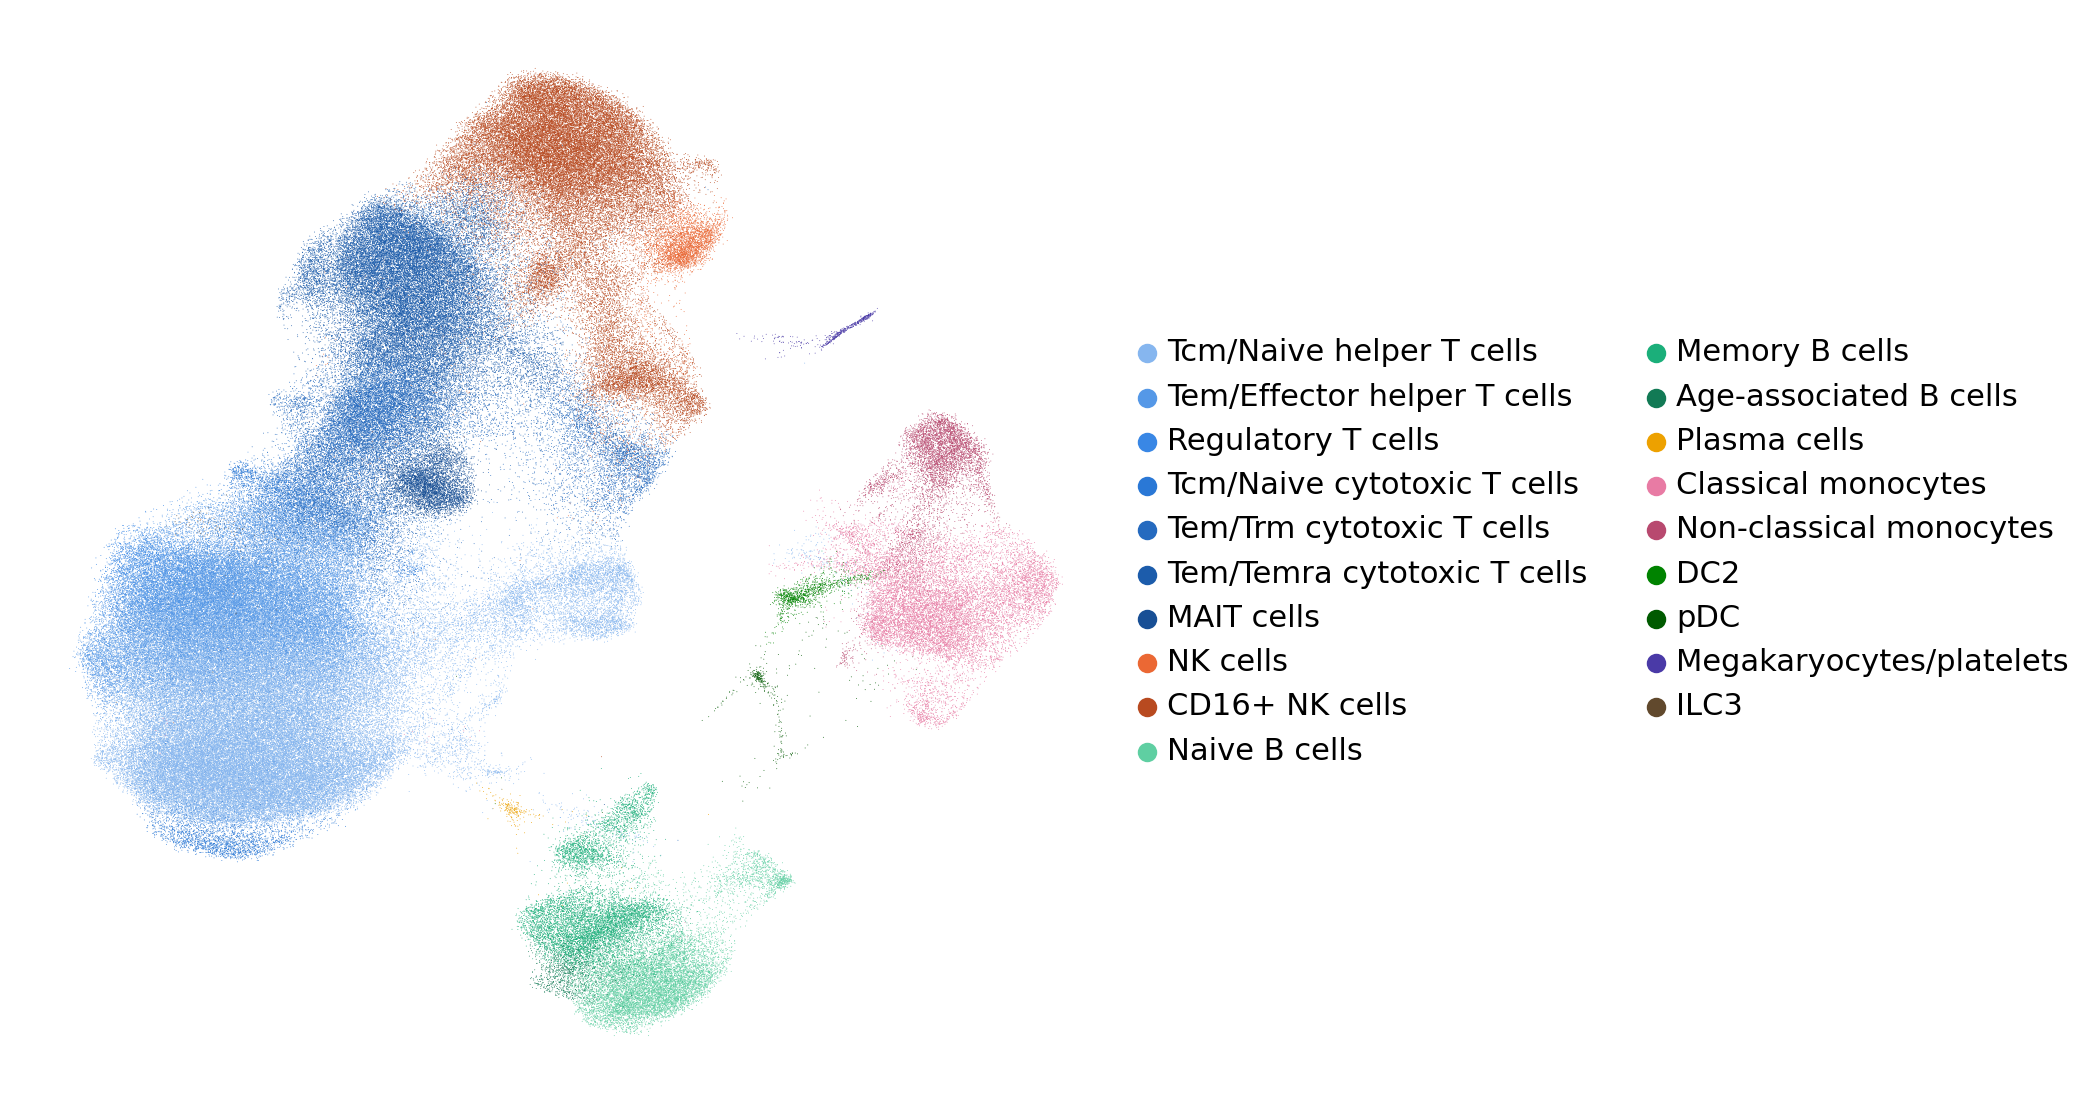

In [ ]:
# plot (fine)

ax = sc.pl.umap(
    adata,
    color=["celltypist_cell_label_fine"],
    frameon=False,
    sort_order=False,
    wspace=2,
    title = "",
    show = False
)

ax.set_aspect("equal")


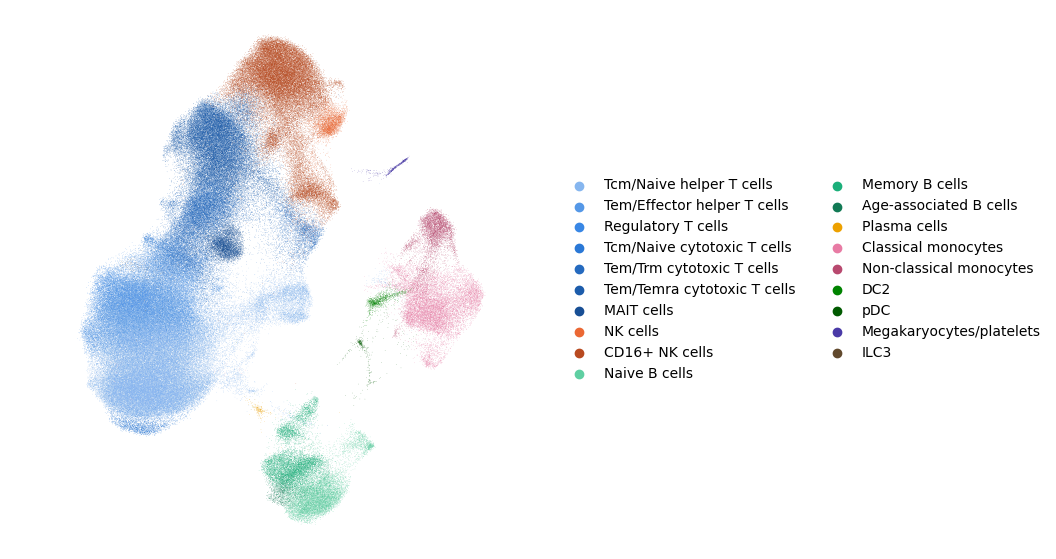

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 7))   # square canvas, sized for the fonts you're using

sc.pl.umap(
    adata,
    color="celltypist_cell_label_fine",
    frameon=False,
    sort_order=False,
    title="",
    ax=ax,            # scanpy draws into MY axes and can't resize it
    show=False,
)

ax.set_aspect("equal", adjustable="datalim")   # datalim expands the view instead of shrinking the box

In [14]:

path2 = "/rds/general/user/ztb25/home/PBMC_datasets/6/PBMC6_clustering.h5ad"

# read only obs + the UMAP embedding — a few MB regardless of how big X is
with h5py.File(path2, "r") as f:
    obs_df = read_elem(f["obs"])
    umap_coords = read_elem(f["obsm"])["X_umap"]

# AnnData with no X at all; shape is (n_cells, 0), which sc.pl.umap is fine with
adata2 = ad.AnnData(obs=obs_df, obsm={"X_umap": umap_coords})


In [22]:
labels = [lab for lab in FINE_COLORS if lab in set(adata2.obs[col].astype(str))]
adata2.obs[col] = pd.Categorical(adata2.obs[col].astype(str), categories=labels, ordered=True)
adata2.uns[f"{col}_colors"] = [FINE_COLORS[lab] for lab in labels]

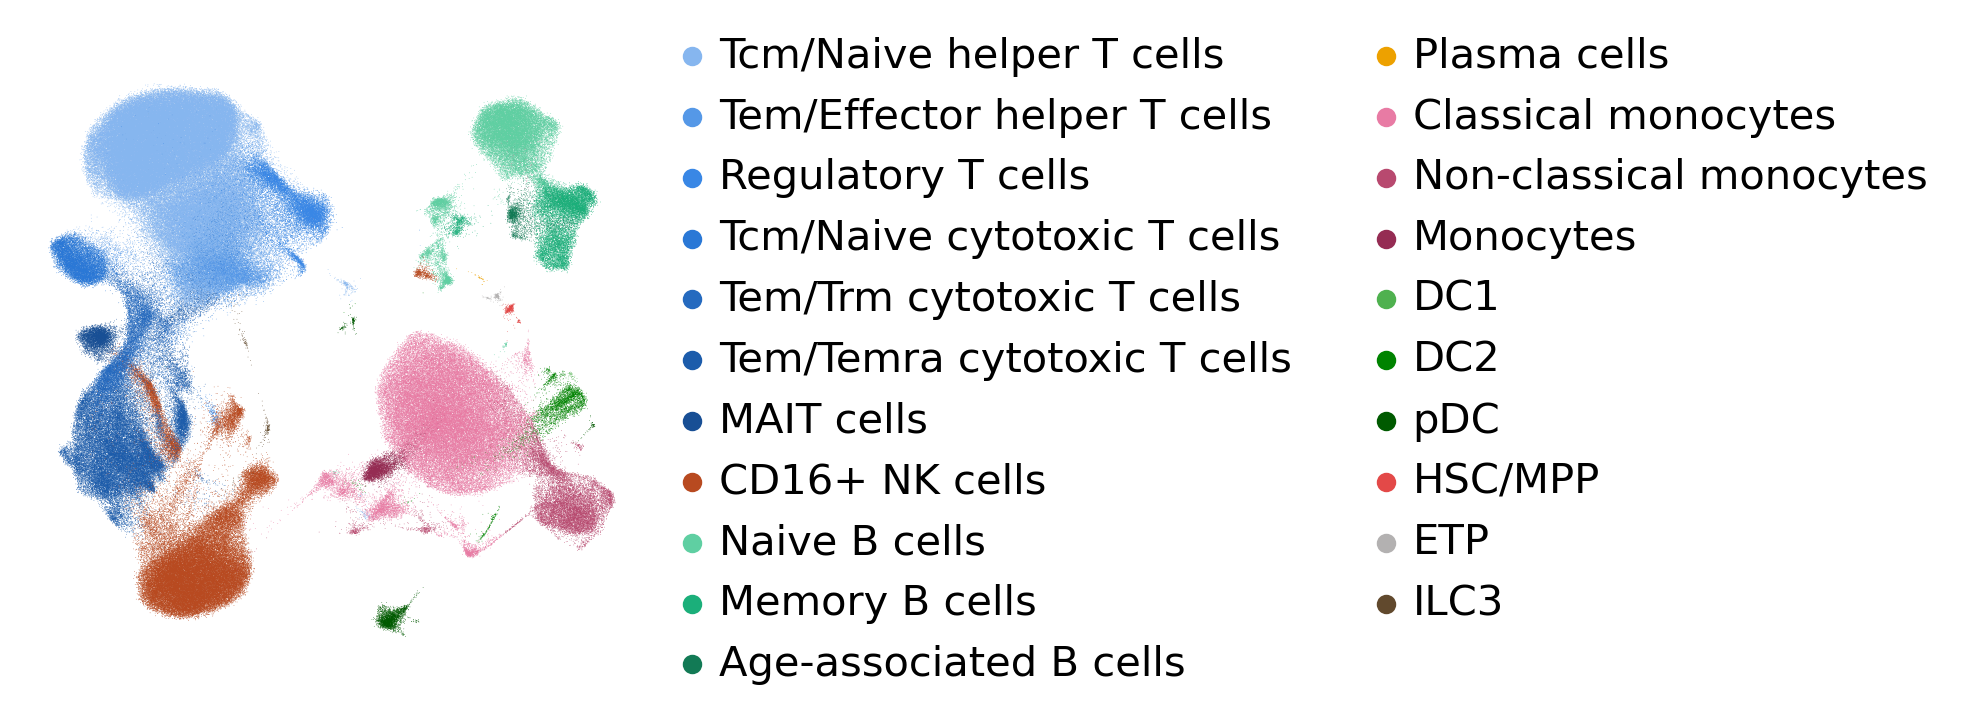

In [26]:
# plot (fine)

sc.pl.umap(
    adata2,
    color=["celltypist_cell_label_fine"],
    frameon=False,
    sort_order=False,
    wspace=2,
    title = ""
)

In [9]:
adata2.obs["celltypist_cell_label_fine"].value_counts()

Tcm/Naive helper T cells       156886
CD16+ NK cells                  64732
Classical monocytes             62744
Tem/Temra cytotoxic T cells     39513
Naive B cells                   26572
Regulatory T cells              17168
Tem/Effector helper T cells     14558
Non-classical monocytes         14558
Tem/Trm cytotoxic T cells       14413
Memory B cells                  12668
Tcm/Naive cytotoxic T cells     10600
MAIT cells                       5579
DC2                              3430
pDC                              2628
Age-associated B cells           1839
HSC/MPP                           428
ILC3                              252
ETP                               172
DC1                                42
Plasma cells                       30
Name: celltypist_cell_label_fine, dtype: int64